# Прогноз концентрации выходного продукта печи по телеметрии

## Цель проекта
Построить модель, которая прогнозирует значение целевого показателя качества в текущий момент времени по минутной телеметрии печи с учетом временной динамики процесса и задержки лабораторных измерений.

## Бизнес-контекст
Лабораторные измерения приходят с задержкой 10–15 минут и нерегулярно. Из-за этого оператор может поздно отреагировать на изменение состояния печи. Модель должна выступать в роли soft sensor — давать оперативную оценку целевого показателя до получения лабораторного результата.

## Исходные данные
- `data_train.csv` — минутная телеметрия
- `target_train.csv` — лабораторные замеры целевого показателя
- `data_test_small.csv` — тестовая телеметрия
- `target_test_small.csv` — тестовые лабораторные замеры

## 1. Импорты и настройки

In [1]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

In [2]:
plt.style.use("default")
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

### Вывод
Подключены библиотеки для:
- обработки данных,
- визуального анализа,
- feature engineering временных рядов,
- обучения и сравнения моделей,
- анализа остатков,
- интерпретации признаков.

## 2. Загрузка данных

In [3]:
import os

print(os.listdir("data"))

['data_test_small.csv', 'data_train.csv', 'target_test_small.csv', 'target_train.csv']


In [4]:
# Локальная структура проекта:
# C:\Python\D
# ├── data/
# │   ├── data_train.csv
# │   ├── target_train.csv
# │   ├── data_test_small.csv
# │   └── target_test_small.csv
# ├── kiln_quality_prediction.ipynb
# └── requirements.txt

DATA_DIR = "data"

required_files = [
    "data_train.csv",
    "target_train.csv",
    "data_test_small.csv",
    "target_test_small.csv",
]

missing_files = [f for f in required_files if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing_files:
    raise FileNotFoundError(f"Не найдены файлы в папке {DATA_DIR}: {missing_files}")

data_train = pd.read_csv(os.path.join(DATA_DIR, "data_train.csv"))
target_train = pd.read_csv(os.path.join(DATA_DIR, "target_train.csv"))
data_test = pd.read_csv(os.path.join(DATA_DIR, "data_test_small.csv"))
target_test = pd.read_csv(os.path.join(DATA_DIR, "target_test_small.csv"))

print("Колонки data_train:", data_train.columns.tolist())
print("Колонки target_train:", target_train.columns.tolist())
print("Колонки data_test:", data_test.columns.tolist())
print("Колонки target_test:", target_test.columns.tolist())

Колонки data_train: ['datetime', 'telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11', 'telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']
Колонки target_train: ['Дата', 'target']
Колонки data_test: ['datetime', 'telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11', 'telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']
Колонки target_test: ['Дата', 'target']


In [5]:
# Приведение колонок с датой к единому имени datetime
for df_name, df in [("data_train", data_train), ("data_test", data_test)]:
    if "datetime" not in df.columns:
        raise KeyError(f"В {df_name} не найдена колонка 'datetime'")

for df_name, df in [("target_train", target_train), ("target_test", target_test)]:
    if "datetime" in df.columns:
        pass
    elif "Дата" in df.columns:
        df.rename(columns={"Дата": "datetime"}, inplace=True)
    else:
        raise KeyError(f"В {df_name} не найдена колонка с датой: ожидается 'datetime' или 'Дата'")

data_train["datetime"] = pd.to_datetime(data_train["datetime"])
data_test["datetime"] = pd.to_datetime(data_test["datetime"])
target_train["datetime"] = pd.to_datetime(target_train["datetime"])
target_test["datetime"] = pd.to_datetime(target_test["datetime"])

# Проверка целевой переменной
target_candidate_cols = [c for c in target_train.columns if c != "datetime"]
if len(target_candidate_cols) != 1:
    raise ValueError(
        f"Ожидалась одна целевая колонка в target_train, но найдено: {target_candidate_cols}"
    )

target_candidate_cols_test = [c for c in target_test.columns if c != "datetime"]
if len(target_candidate_cols_test) != 1:
    raise ValueError(
        f"Ожидалась одна целевая колонка в target_test, но найдено: {target_candidate_cols_test}"
    )

In [6]:
print("data_train shape:", data_train.shape)
print("target_train shape:", target_train.shape)
print("data_test shape:", data_test.shape)
print("target_test shape:", target_test.shape)

display(data_train.head())
display(target_train.head())

data_train shape: (319546, 17)
target_train shape: (1773, 2)
data_test shape: (39943, 17)
target_test shape: (318, 2)


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


,datetime,target
0,2019-03-13 17:00:00,0.123711
1,2019-03-13 21:00:00,0.319588
2,2019-03-14 01:00:00,0.255155
3,2019-03-14 05:00:00,0.319588
4,2019-03-14 09:00:00,0.159794


### Вывод
Данные загружены. Далее нужно проверить временные диапазоны, частоты наблюдений, пропуски, аномалии и структуру целевой переменной.

## 3. Первичная проверка временных диапазонов

In [7]:
print("data_train:", data_train["datetime"].min(), "->", data_train["datetime"].max())
print("target_train:", target_train["datetime"].min(), "->", target_train["datetime"].max())

print("data_test:", data_test["datetime"].min(), "->", data_test["datetime"].max())
print("target_test:", target_test["datetime"].min(), "->", target_test["datetime"].max())

data_train: 2019-03-01 00:01:00 -> 2019-10-07 19:58:00
target_train: 2019-03-13 17:00:00 -> 2019-10-07 21:00:00
data_test: 2019-10-07 19:59:00 -> 2019-11-04 10:25:00
target_test: 2019-10-07 23:00:00 -> 2019-11-04 09:00:00


### Вывод
Исправленный `data_train.csv` почти полностью покрывает временной диапазон `target_train`, поэтому основная часть лабораторных замеров может быть корректно сопоставлена с телеметрией.

Однако таргет нельзя привязывать к телеметрии в тот же момент времени: лабораторный результат относится к состоянию процесса в момент отбора пробы, который произошел раньше примерно на 10–15 минут.

## 4. EDA: структура и качество данных

### 4.1 Типы данных и список признаков

In [8]:
print(data_train.dtypes)
print(target_train.dtypes)

telemetry_cols = [c for c in data_train.columns if c.startswith("telemetry_")]
print("Количество телеметрических признаков:", len(telemetry_cols))
print(telemetry_cols)

datetime        datetime64[us]
telemetry_0            float64
telemetry_1            float64
telemetry_2            float64
telemetry_3            float64
telemetry_4            float64
telemetry_5            float64
telemetry_6            float64
telemetry_7            float64
telemetry_8            float64
telemetry_9            float64
telemetry_10           float64
telemetry_11           float64
telemetry_12           float64
telemetry_13           float64
telemetry_14           float64
telemetry_15           float64
dtype: object
datetime    datetime64[us]
target             float64
dtype: object
Количество телеметрических признаков: 16
['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11', 'telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']


### 4.2 Частота наблюдений

In [9]:
data_train = data_train.sort_values("datetime").reset_index(drop=True)
target_train = target_train.sort_values("datetime").reset_index(drop=True)
data_test = data_test.sort_values("datetime").reset_index(drop=True)
target_test = target_test.sort_values("datetime").reset_index(drop=True)

display(data_train["datetime"].diff().value_counts().head(10))
display(target_train["datetime"].diff().value_counts().head(10))

datetime
0 days 00:01:00    317997
0 days 00:00:00      1548
Name: count, dtype: int64

datetime
0 days 02:00:00     1570
0 days 04:00:00      184
0 days 01:00:00        4
0 days 07:00:00        2
0 days 01:30:00        1
18 days 08:30:00       1
0 days 11:00:00        1
0 days 14:00:00        1
9 days 06:00:00        1
9 days 14:00:00        1
Name: count, dtype: int64

### Вывод
Телеметрия имеет минутную частоту. Лабораторные замеры поступают существенно реже и нерегулярно. Следовательно, задача требует специальной синхронизации двух временных источников.

### 4.3 Пропуски

In [10]:
missing_summary = pd.DataFrame({
    "missing_ratio": data_train.isna().mean(),
    "missing_count": data_train.isna().sum()
}).sort_values("missing_ratio", ascending=False)

display(missing_summary)

,missing_ratio,missing_count
telemetry_12,0.993434,317448
telemetry_14,0.993434,317448
telemetry_13,0.993434,317448
telemetry_15,0.993434,317448
telemetry_4,0.000416,133
telemetry_5,0.000053,17
telemetry_0,0.000053,17
telemetry_7,0.000050,16
telemetry_1,0.000050,16
telemetry_11,0.000050,16


### Вывод
Признаки с экстремально высокой долей пропусков не должны использоваться в модели без дополнительного обоснования. В производственном контексте это означает, что соответствующие датчики дают недостаточно надежную информацию.

### 4.4 Визуальный анализ телеметрии

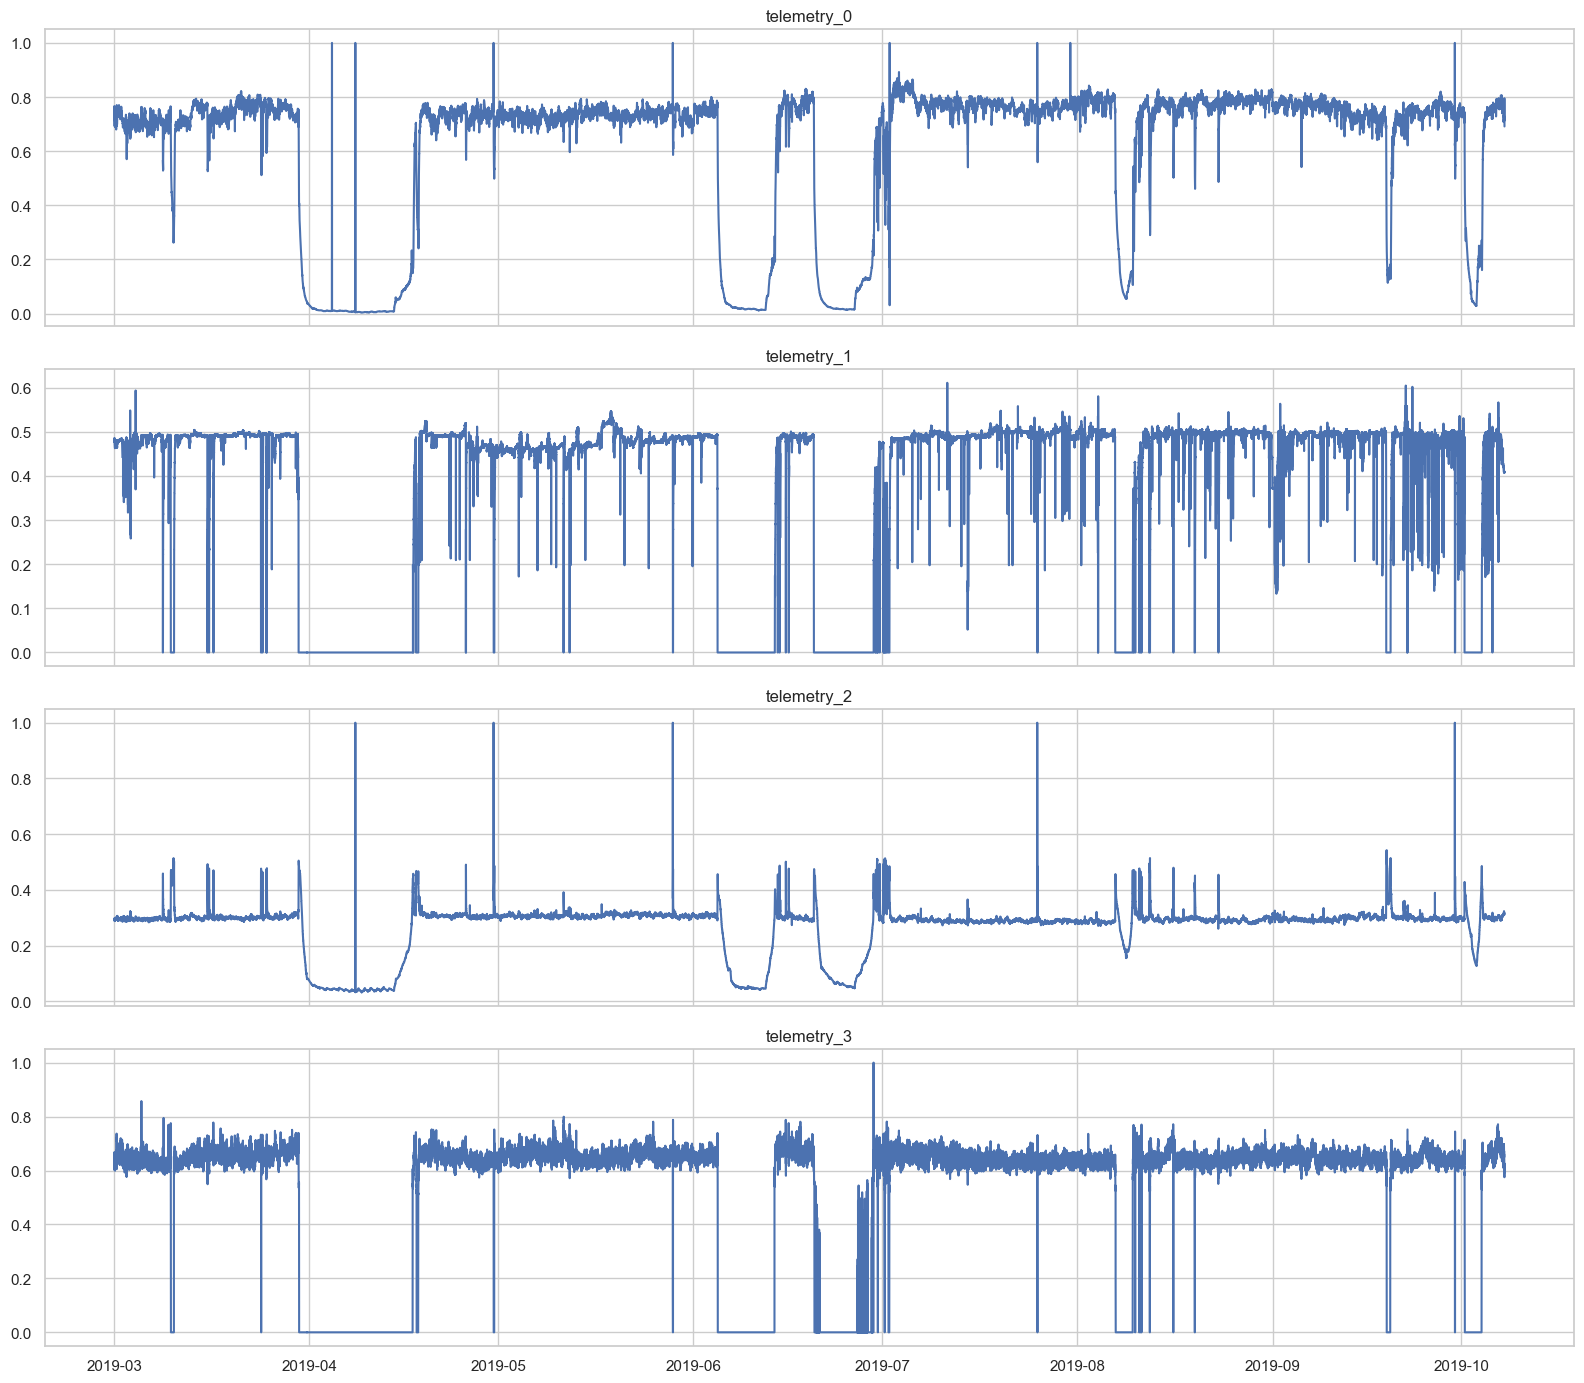

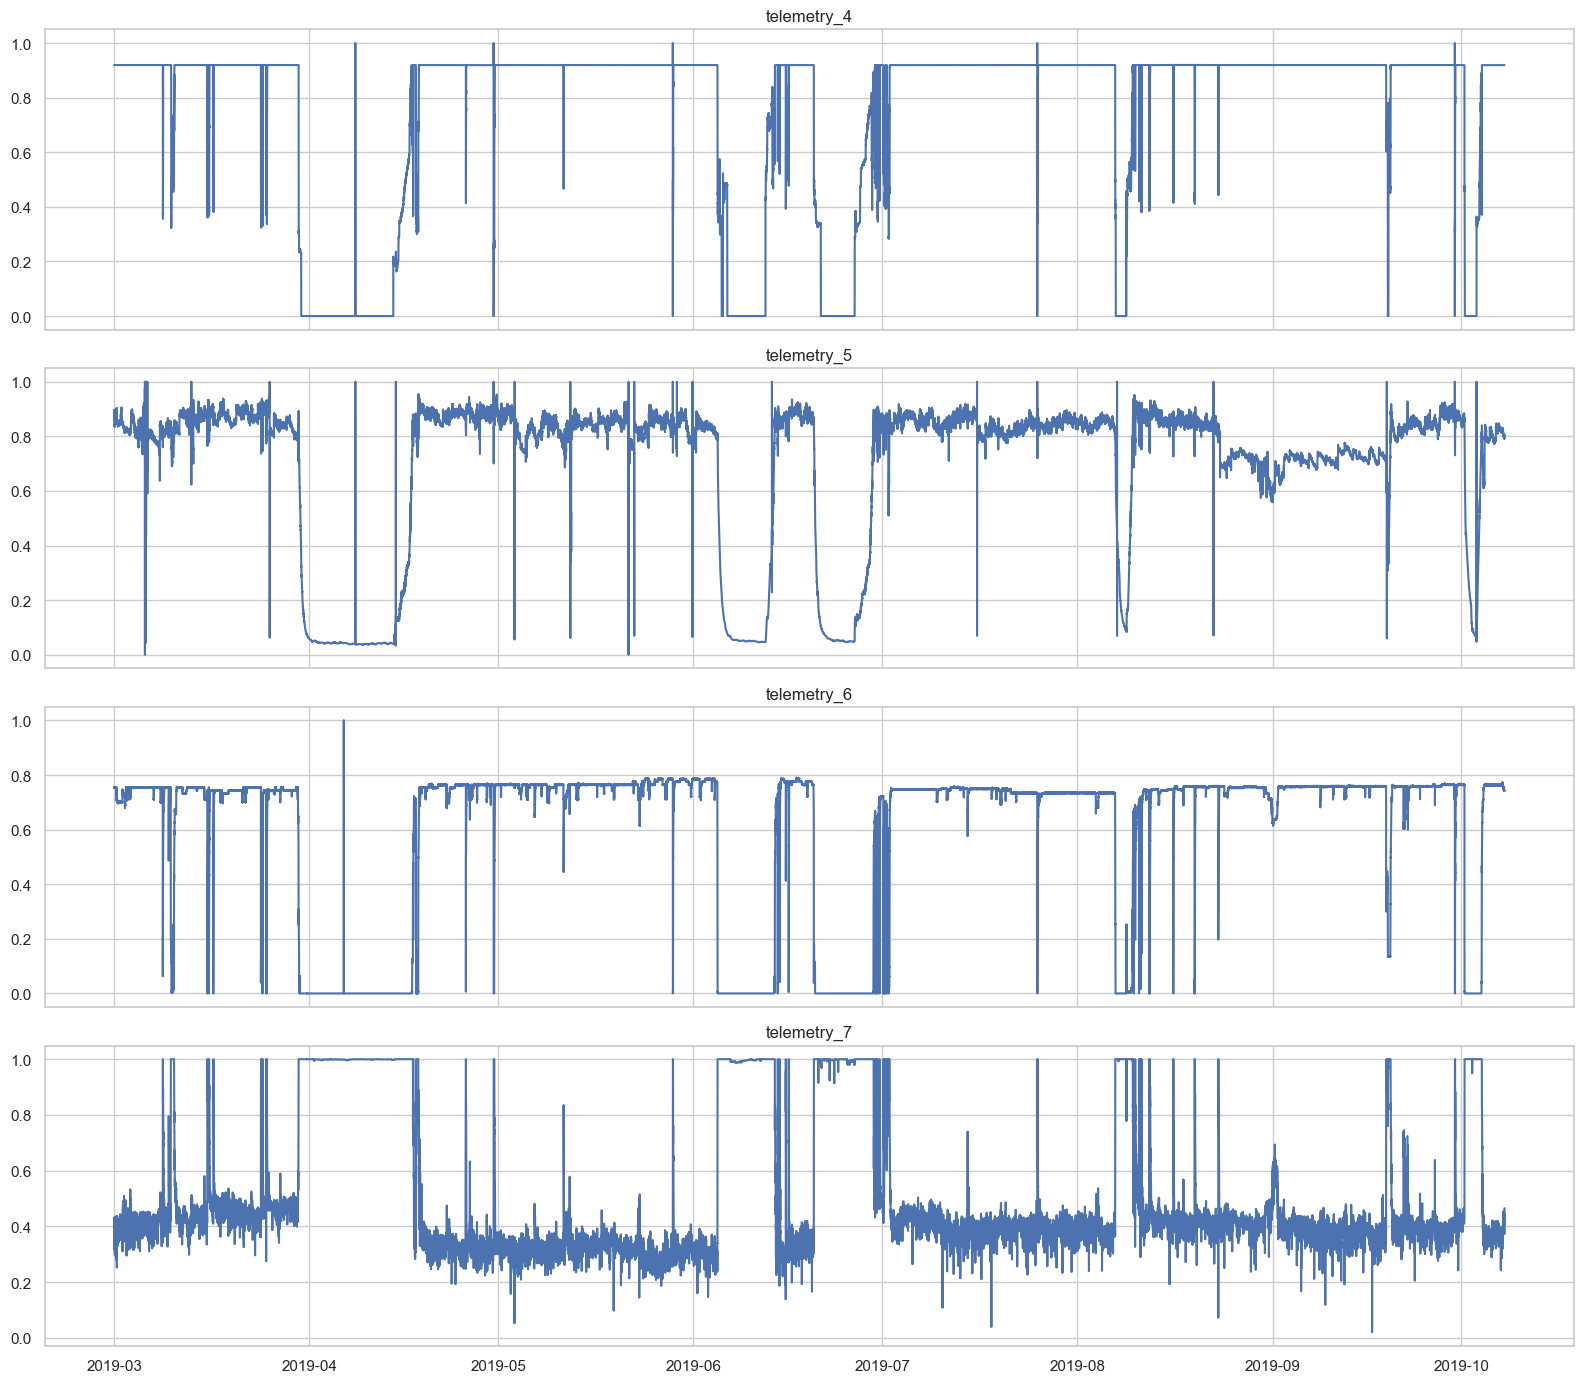

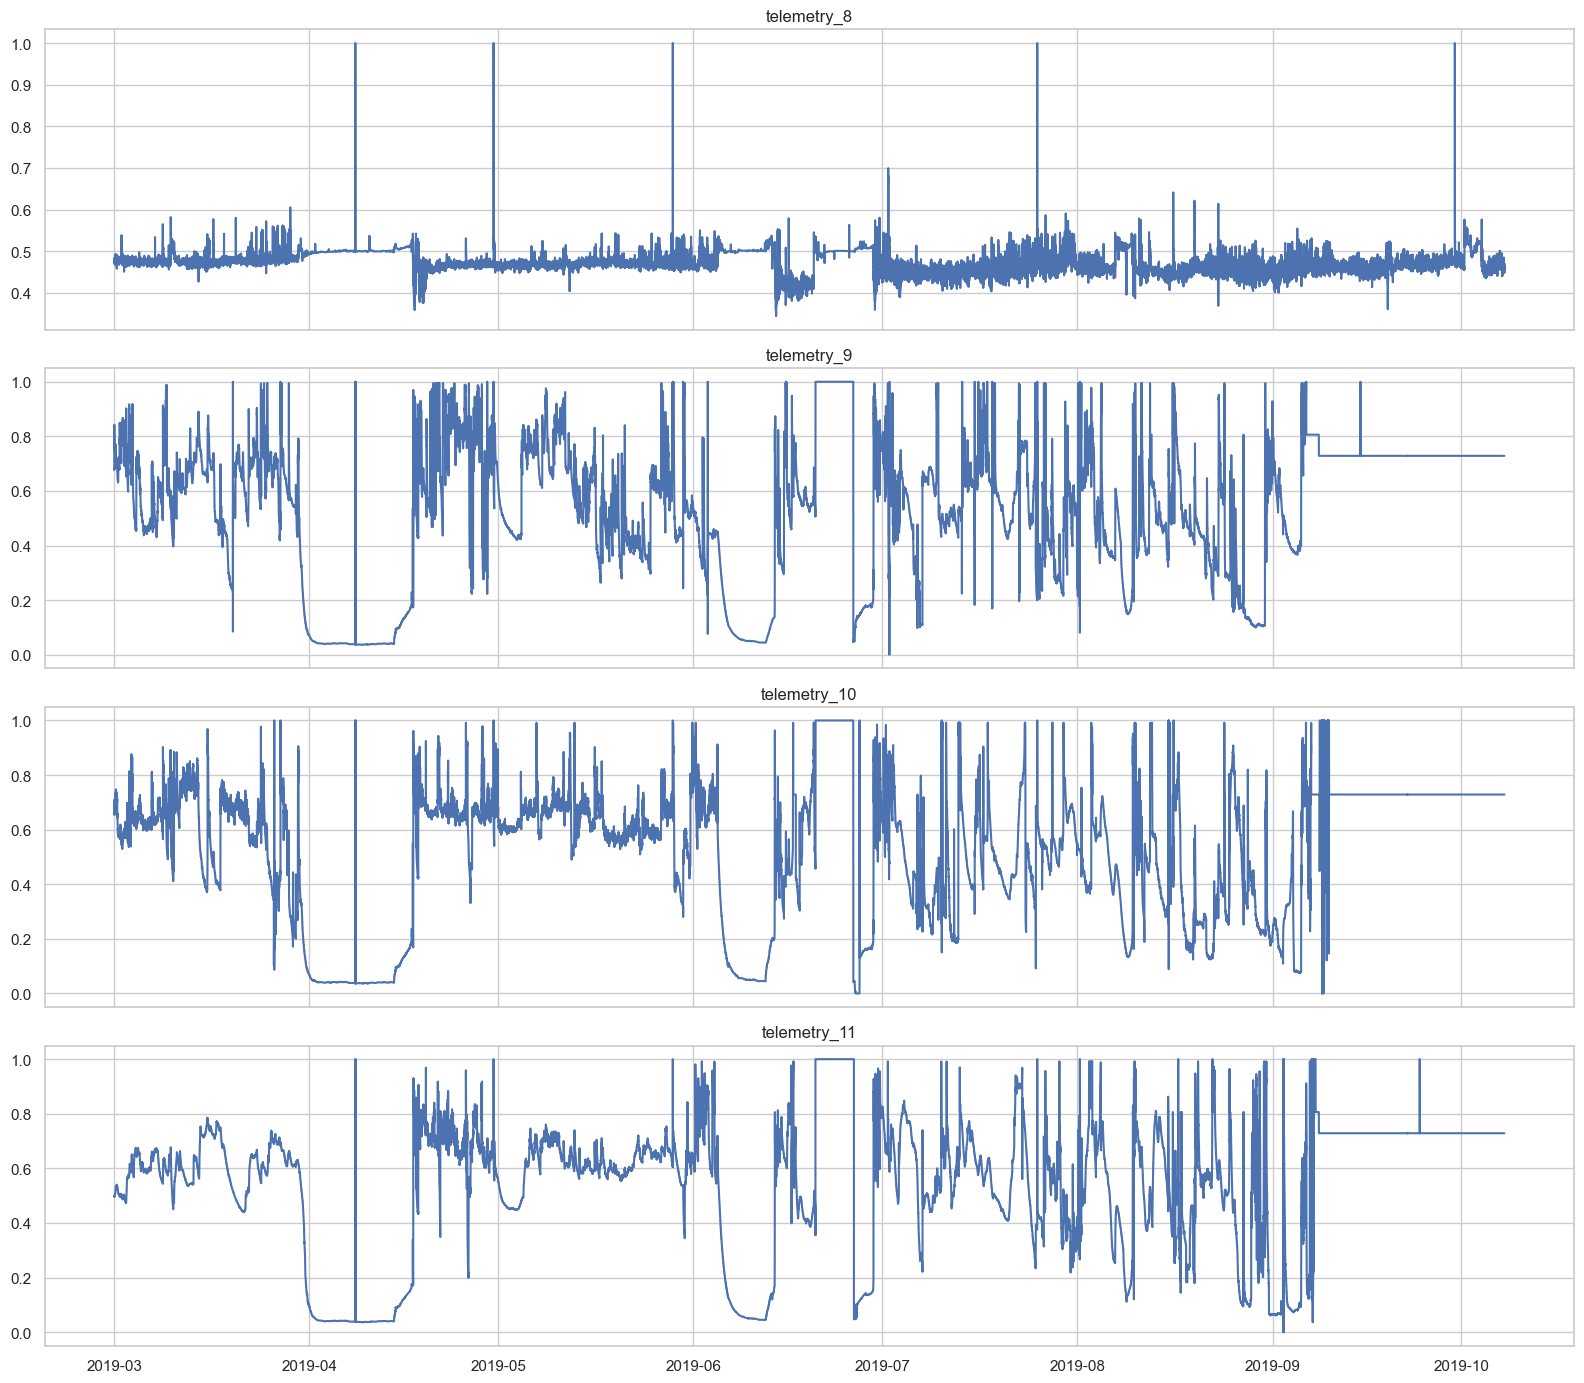

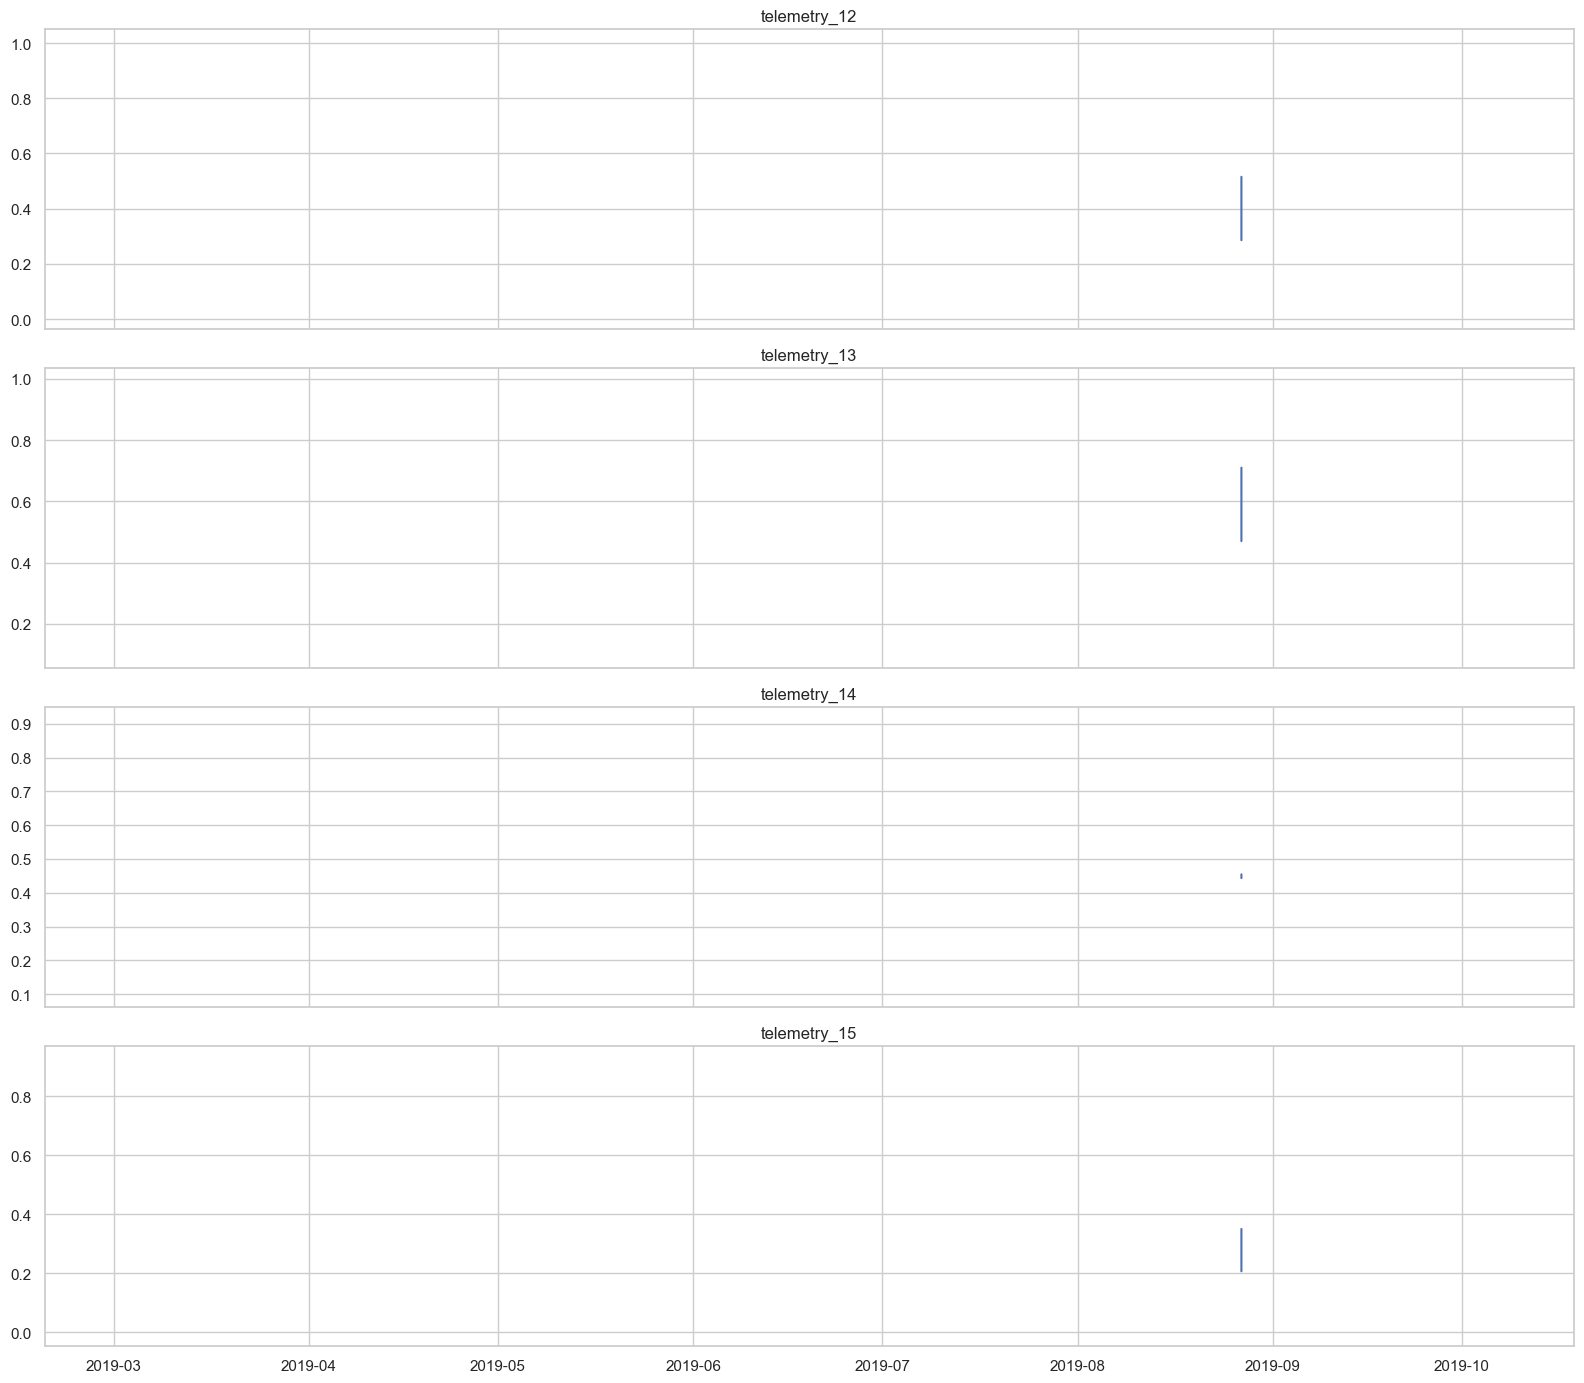

In [11]:
for start in range(0, len(telemetry_cols), 4):
    subset = telemetry_cols[start:start+4]
    fig, axes = plt.subplots(len(subset), 1, figsize=(16, 3.5 * len(subset)), sharex=True)
    if len(subset) == 1:
        axes = [axes]
    for ax, col in zip(axes, subset):
        ax.plot(data_train["datetime"], data_train[col])
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

### На что смотрим
- тренды,
- скачки,
- выбросы,
- периодичность,
- участки с постоянными значениями,
- разрывы и пропуски.

### 4.5 Исследование целевой переменной

Целевая переменная: target


count    1773.000000
mean        0.254272
std         0.092208
min         0.000000
25%         0.175258
50%         0.247423
75%         0.314433
max         0.716495
Name: target, dtype: float64

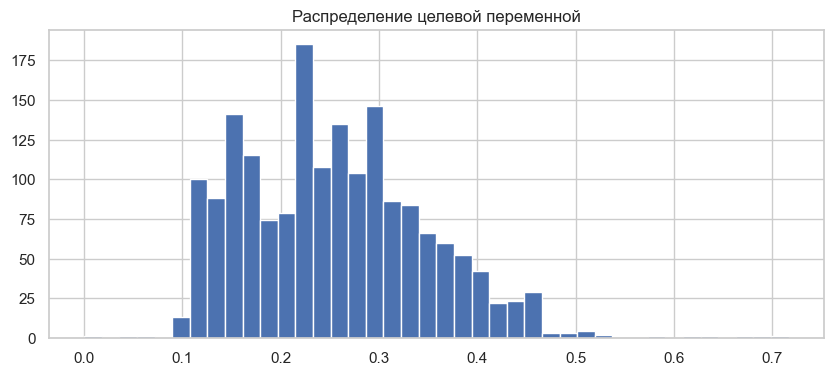

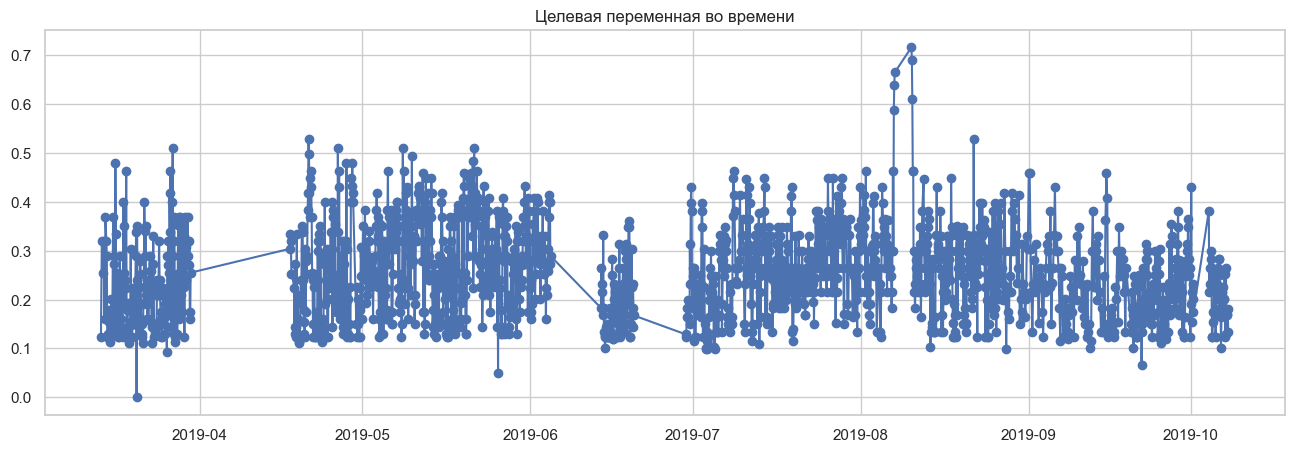

In [12]:
target_cols_train = [c for c in target_train.columns if c != "datetime"]
target_cols_test = [c for c in target_test.columns if c != "datetime"]

if len(target_cols_train) != 1 or len(target_cols_test) != 1:
    raise ValueError(
        f"Не удалось однозначно определить target. "
        f"target_train: {target_cols_train}, target_test: {target_cols_test}"
    )

if target_cols_train[0] != target_cols_test[0]:
    raise ValueError(
        f"Названия целевой колонки в train/test не совпадают: "
        f"{target_cols_train[0]} vs {target_cols_test[0]}"
    )

target_col = target_cols_train[0]
print("Целевая переменная:", target_col)

display(target_train[target_col].describe())

plt.figure(figsize=(10, 4))
target_train[target_col].hist(bins=40)
plt.title("Распределение целевой переменной")
plt.show()

plt.figure(figsize=(16, 5))
plt.plot(target_train["datetime"], target_train[target_col], marker="o", linestyle="-")
plt.title("Целевая переменная во времени")
plt.show()

### Вывод
Целевая переменная доступна только в отдельных временных точках. Поэтому модель должна обучаться не на каждой минуте, а на синхронизированных событиях, где каждому лабораторному измерению сопоставляется телеметрический контекст из прошлого.

### 4.6 Корреляционный анализ с лагами

In [13]:
candidate_cols = telemetry_cols[: min(6, len(telemetry_cols))]
lags = [0, 5, 10, 15, 30, 60]

corr_results = []

for col in candidate_cols:
    for lag in lags:
        tmp = data_train[["datetime", col]].copy()
        tmp["datetime_shifted"] = tmp["datetime"] + pd.to_timedelta(lag, unit="m")

        merged = pd.merge_asof(
            target_train.sort_values("datetime"),
            tmp.sort_values("datetime_shifted")[["datetime_shifted", col]],
            left_on="datetime",
            right_on="datetime_shifted",
            direction="backward"
        )

        corr = merged[[target_col, col]].corr().iloc[0, 1]
        corr_results.append({"feature": col, "lag_min": lag, "corr": corr})

corr_df = pd.DataFrame(corr_results).sort_values("corr", key=lambda s: s.abs(), ascending=False)
display(corr_df.head(20))

,feature,lag_min,corr
0,telemetry_0,0,-0.186001
1,telemetry_0,5,-0.185633
2,telemetry_0,10,-0.182428
22,telemetry_3,30,-0.177916
3,telemetry_0,15,-0.176359
4,telemetry_0,30,-0.169951
23,telemetry_3,60,-0.158373
5,telemetry_0,60,-0.151401
21,telemetry_3,15,-0.126282
20,telemetry_3,10,-0.118444


### Вывод
Корреляционный анализ с лагами позволяет оценить, какие датчики связаны с целевым показателем и при каком временном смещении связь выражена сильнее. Для печи это важно, так как влияние режима на качество продукта проявляется с инерцией.

## 5. Обработка пропусков и подготовка телеметрии

In [14]:
high_missing_cols = missing_summary.loc[missing_summary["missing_ratio"] > 0.95].index.tolist()
print("Признаки с долей пропусков > 95%:")
print(high_missing_cols)

telemetry_model_cols = [c for c in telemetry_cols if c not in high_missing_cols]
print("Признаки, оставленные для моделирования:", telemetry_model_cols)

Признаки с долей пропусков > 95%:
['telemetry_12', 'telemetry_14', 'telemetry_13', 'telemetry_15']
Признаки, оставленные для моделирования: ['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11']


In [15]:
telemetry_df = data_train[["datetime"] + telemetry_model_cols].copy().sort_values("datetime").reset_index(drop=True)

# Для минутной технологической телеметрии разумно считать, что соседние значения по времени близки.
# Поэтому используем мягкое заполнение пропусков.
telemetry_df[telemetry_model_cols] = telemetry_df[telemetry_model_cols].ffill().bfill()

display(telemetry_df.head())

,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407


### Вывод
Стратегия обработки пропусков:
1. Почти пустые признаки исключаются.
2. Для остальных используется `ffill/bfill`.

Такой подход уменьшает потерю данных и соответствует непрерывному характеру производственного процесса.

## 6. Feature engineering

In [16]:
def add_time_features(df):
    df = df.copy()
    df["hour"] = df["datetime"].dt.hour
    df["dayofweek"] = df["datetime"].dt.dayofweek
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    return df

def add_lag_features(df, cols, lags=(1, 5, 10, 15, 30, 60)):
    df = df.copy()
    for col in cols:
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    return df

def add_rolling_features(df, cols, windows=(5, 15, 30, 60)):
    df = df.copy()
    for col in cols:
        for w in windows:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(w).mean()
            df[f"{col}_roll_std_{w}"] = df[col].rolling(w).std()
            df[f"{col}_roll_min_{w}"] = df[col].rolling(w).min()
            df[f"{col}_roll_max_{w}"] = df[col].rolling(w).max()
    return df

def add_diff_features(df, cols):
    df = df.copy()
    for col in cols:
        df[f"{col}_diff_1"] = df[col].diff(1)
        df[f"{col}_diff_5"] = df[col].diff(5)
        # деление на 0 исключаем
        base = df[col].shift(5).replace(0, np.nan)
        df[f"{col}_pct_change_5"] = (df[col] - base) / base
    return df

In [17]:
telemetry_features = telemetry_df.copy()
telemetry_features = add_time_features(telemetry_features)
telemetry_features = add_lag_features(telemetry_features, telemetry_model_cols)
telemetry_features = add_rolling_features(telemetry_features, telemetry_model_cols)
telemetry_features = add_diff_features(telemetry_features, telemetry_model_cols)

print("Размерность таблицы признаков:", telemetry_features.shape)
display(telemetry_features.head())

Размерность таблицы признаков: (319546, 317)


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,hour,dayofweek,hour_sin,hour_cos,telemetry_0_lag_1,telemetry_0_lag_5,telemetry_0_lag_10,telemetry_0_lag_15,telemetry_0_lag_30,telemetry_0_lag_60,telemetry_1_lag_1,telemetry_1_lag_5,telemetry_1_lag_10,telemetry_1_lag_15,telemetry_1_lag_30,telemetry_1_lag_60,telemetry_2_lag_1,telemetry_2_lag_5,telemetry_2_lag_10,telemetry_2_lag_15,telemetry_2_lag_30,telemetry_2_lag_60,telemetry_3_lag_1,telemetry_3_lag_5,telemetry_3_lag_10,telemetry_3_lag_15,telemetry_3_lag_30,telemetry_3_lag_60,telemetry_4_lag_1,telemetry_4_lag_5,telemetry_4_lag_10,telemetry_4_lag_15,telemetry_4_lag_30,telemetry_4_lag_60,telemetry_5_lag_1,telemetry_5_lag_5,telemetry_5_lag_10,telemetry_5_lag_15,telemetry_5_lag_30,telemetry_5_lag_60,telemetry_6_lag_1,telemetry_6_lag_5,telemetry_6_lag_10,telemetry_6_lag_15,telemetry_6_lag_30,telemetry_6_lag_60,telemetry_7_lag_1,telemetry_7_lag_5,telemetry_7_lag_10,telemetry_7_lag_15,telemetry_7_lag_30,telemetry_7_lag_60,telemetry_8_lag_1,telemetry_8_lag_5,telemetry_8_lag_10,telemetry_8_lag_15,telemetry_8_lag_30,telemetry_8_lag_60,telemetry_9_lag_1,telemetry_9_lag_5,telemetry_9_lag_10,telemetry_9_lag_15,telemetry_9_lag_30,telemetry_9_lag_60,telemetry_10_lag_1,telemetry_10_lag_5,telemetry_10_lag_10,telemetry_10_lag_15,telemetry_10_lag_30,telemetry_10_lag_60,telemetry_11_lag_1,telemetry_11_lag_5,telemetry_11_lag_10,telemetry_11_lag_15,telemetry_11_lag_30,telemetry_11_lag_60,telemetry_0_roll_mean_5,telemetry_0_roll_std_5,telemetry_0_roll_min_5,telemetry_0_roll_max_5,telemetry_0_roll_mean_15,telemetry_0_roll_std_15,telemetry_0_roll_min_15,telemetry_0_roll_max_15,telemetry_0_roll_mean_30,telemetry_0_roll_std_30,telemetry_0_roll_min_30,telemetry_0_roll_max_30,telemetry_0_roll_mean_60,telemetry_0_roll_std_60,telemetry_0_roll_min_60,telemetry_0_roll_max_60,telemetry_1_roll_mean_5,telemetry_1_roll_std_5,telemetry_1_roll_min_5,telemetry_1_roll_max_5,telemetry_1_roll_mean_15,telemetry_1_roll_std_15,telemetry_1_roll_min_15,telemetry_1_roll_max_15,telemetry_1_roll_mean_30,telemetry_1_roll_std_30,telemetry_1_roll_min_30,telemetry_1_roll_max_30,telemetry_1_roll_mean_60,telemetry_1_roll_std_60,telemetry_1_roll_min_60,telemetry_1_roll_max_60,telemetry_2_roll_mean_5,telemetry_2_roll_std_5,telemetry_2_roll_min_5,telemetry_2_roll_max_5,telemetry_2_roll_mean_15,telemetry_2_roll_std_15,telemetry_2_roll_min_15,telemetry_2_roll_max_15,telemetry_2_roll_mean_30,telemetry_2_roll_std_30,telemetry_2_roll_min_30,telemetry_2_roll_max_30,telemetry_2_roll_mean_60,telemetry_2_roll_std_60,telemetry_2_roll_min_60,telemetry_2_roll_max_60,telemetry_3_roll_mean_5,telemetry_3_roll_std_5,telemetry_3_roll_min_5,telemetry_3_roll_max_5,telemetry_3_roll_mean_15,telemetry_3_roll_std_15,telemetry_3_roll_min_15,telemetry_3_roll_max_15,telemetry_3_roll_mean_30,telemetry_3_roll_std_30,telemetry_3_roll_min_30,telemetry_3_roll_max_30,telemetry_3_roll_mean_60,...,telemetry_4_roll_min_60,telemetry_4_roll_max_60,telemetry_5_roll_mean_5,telemetry_5_roll_std_5,telemetry_5_roll_min_5,telemetry_5_roll_max_5,telemetry_5_roll_mean_15,telemetry_5_roll_std_15,telemetry_5_roll_min_15,telemetry_5_roll_max_15,telemetry_5_roll_mean_30,telemetry_5_roll_std_30,telemetry_5_roll_min_30,telemetry_5_roll_max_30,telemetry_5_roll_mean_60,telemetry_5_roll_std_60,telemetry_5_roll_min_60,telemetry_5_roll_max_60,telemetry_6_roll_mean_5,telemetry_6_roll_std_5,telemetry_6_roll_min_5,telemetry_6_roll_max_5,telemetry_6_roll_mean_15,telemetry_6_roll_std_15,telemetry_6_roll_min_15,telemetry_6_roll_max_15,telemetry_6_roll_mean_30,telemetry_6_roll_std_30,telemetry_6_roll_min_30,telemetry_6_roll_max_30,telemetry_6_roll_mean_60,telemetry_6_roll_std_60,telemetry_6_roll_min_60,telemetry_6_roll_max_60,telemetry_7_roll_mean_5,telemetry_7_roll_std_5,telemetry_7_roll_min_5,telemetry_7_roll_max_5,telemetry_7_roll_mean_15,telemetry_7_roll_std_15,telemetry_7_roll_min_15,telem

### Вывод
Сформированы:
- лаговые признаки,
- скользящие статистики,
- признаки динамики,
- временные признаки.

Это позволяет описывать не только текущее состояние печи, но и историю ее режима.

## 7. Синхронизация телеметрии и лабораторных измерений

In [18]:
def make_supervised_dataset(telemetry_features, target_df, target_col, delay_minutes=12):
    y = target_df.copy().sort_values("datetime")
    y["telemetry_time"] = y["datetime"] - pd.to_timedelta(delay_minutes, unit="m")

    merged = pd.merge_asof(
        y.sort_values("telemetry_time"),
        telemetry_features.sort_values("datetime"),
        left_on="telemetry_time",
        right_on="datetime",
        direction="backward"
    )

    merged = merged.rename(columns={
        "datetime_x": "target_datetime",
        "datetime_y": "feature_datetime"
    })
    return merged

In [19]:
candidate_delays = [10, 12, 15]
delay_datasets = {}

for delay in candidate_delays:
    ds = make_supervised_dataset(telemetry_features, target_train, target_col, delay_minutes=delay)
    delay_datasets[delay] = ds
    print(f"delay={delay}: shape={ds.shape}, missing_total={ds.isna().mean().mean():.4f}")

delay=10: shape=(1773, 320), missing_total=0.0000
delay=12: shape=(1773, 320), missing_total=0.0000
delay=15: shape=(1773, 320), missing_total=0.0000


### Вывод
Лабораторный результат относится не к моменту получения ответа, а к моменту отбора пробы. Поэтому обучение должно происходить на данных, где телеметрия сдвинута назад на 10–15 минут относительно времени лабораторного замера.

## 8. Формирование обучающей выборки

In [20]:
selected_delay = 12  # временно; далее его можно обновить по результатам CV
train_ds = delay_datasets[selected_delay].copy()

print("Размер до очистки:", train_ds.shape)
print("Суммарное число пропусков до очистки:", int(train_ds.isna().sum().sum()))

train_ds = train_ds.dropna(subset=[target_col]).copy()

exclude_cols = ["target_datetime", "feature_datetime", "telemetry_time", target_col]
feature_candidate_cols = [c for c in train_ds.columns if c not in exclude_cols]

# Удаляем только строки, где признаки не сформировались из-за лагов/окон
train_ds = train_ds.dropna(subset=feature_candidate_cols).reset_index(drop=True)

print("Размер после очистки:", train_ds.shape)
print("Суммарное число пропусков после очистки:", int(train_ds.isna().sum().sum()))

feature_cols = [c for c in train_ds.columns if c not in exclude_cols]

X = train_ds[feature_cols]
y = train_ds[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

Размер до очистки: (1773, 320)
Суммарное число пропусков до очистки: 21
Размер после очистки: (1762, 320)
Суммарное число пропусков после очистки: 0
X shape: (1762, 316)
y shape: (1762,)


### Вывод
Подготовлена обучающая выборка без утечки из будущего: все признаки относятся к текущему и прошлому состоянию телеметрии, а целевое значение берется из лаборатории.

## 9. Метрики и кросс-валидация

In [21]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def wape(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.maximum(np.sum(np.abs(y_true)), eps) * 100

def direction_accuracy(y_true, y_pred):
    if len(y_true) < 2:
        return np.nan
    true_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    return np.mean(true_diff == pred_diff)

def evaluate_model_cv(model, X, y, splitter):
    rows = []

    for fold, (train_idx, val_idx) in enumerate(splitter.split(X), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        start = time.time()
        model.fit(X_train, y_train)
        fit_time = time.time() - start

        pred = model.predict(X_val)

        rows.append({
            "fold": fold,
            "MAE": mean_absolute_error(y_val, pred),
            "RMSE": rmse(y_val, pred),
            "MAPE": mape(y_val, pred),
            "WAPE": wape(y_val, pred),
            "Direction_Accuracy": direction_accuracy(y_val.values, pred),
            "fit_time_sec": fit_time
        })

    return pd.DataFrame(rows)

### Почему выбран именно такой способ валидации
Используется `TimeSeriesSplit`, потому что обычное случайное разбиение создает утечку будущего и делает оценку качества недостоверной.

## 10. Обоснование выбора моделей

### Подходящие модели
1. **Ridge Regression** — интерпретируемый линейный baseline.  
2. **Random Forest Regressor** — устойчив к шуму, учитывает нелинейности.  
3. **Gradient Boosting Regressor / XGBoost** — сильный подход для табличных данных с ручным feature engineering.

### Какие модели не подходят и почему
- **Random train/test split** — ломает временную структуру и дает leakage.
- **KNN Regressor** — слаб на высокоразмерных лаговых признаках, чувствителен к шуму.
- **Чистая ARIMA только по target** — плохо подходит из-за редких и нерегулярных лабораторных измерений и игнорирования телеметрии.
- **LSTM/GRU** — теоретически возможны, но для такого задания избыточны, тяжелее в разработке и хуже интерпретируются.

## 11. Обучение и сравнение моделей

In [22]:
tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

In [23]:
cv_results = {}
summary_rows = []

for name, model in models.items():
    res = evaluate_model_cv(model, X, y, tscv)
    cv_results[name] = res

    summary_rows.append({
        "model": name,
        "MAE": res["MAE"].mean(),
        "RMSE": res["RMSE"].mean(),
        "MAPE": res["MAPE"].mean(),
        "WAPE": res["WAPE"].mean(),
        "Direction_Accuracy": res["Direction_Accuracy"].mean(),
        "fit_time_sec": res["fit_time_sec"].mean()
    })

summary = pd.DataFrame(summary_rows).sort_values("RMSE").reset_index(drop=True)
display(summary)

,model,MAE,RMSE,MAPE,WAPE,Direction_Accuracy,fit_time_sec
0,RandomForest,0.070694,0.088239,31.842484,27.566179,0.535616,1.420494
1,GradientBoosting,0.072748,0.090534,32.716950,28.320368,0.517808,10.710415
2,Ridge,0.072447,0.090800,32.699785,28.243049,0.526712,0.010816


### Вывод
Сравнение baseline-модели и ансамблевых подходов показывает, насколько линейной или нелинейной является связь между телеметрией и целевым показателем.

## 12. Подбор задержки между телеметрией и лабораторией

In [24]:
delay_results = []

for delay in [10, 12, 15]:
    ds = delay_datasets[delay].copy()
    ds = ds.dropna(subset=[target_col]).dropna().reset_index(drop=True)

    exclude_cols = ["target_datetime", "feature_datetime", "telemetry_time", target_col]
    feature_cols_delay = [c for c in ds.columns if c not in exclude_cols]

    X_delay = ds[feature_cols_delay]
    y_delay = ds[target_col]

    model = Ridge(alpha=1.0)
    cv_res = evaluate_model_cv(model, X_delay, y_delay, TimeSeriesSplit(n_splits=5))

    delay_results.append({
        "delay_minutes": delay,
        "MAE": cv_res["MAE"].mean(),
        "RMSE": cv_res["RMSE"].mean(),
        "MAPE": cv_res["MAPE"].mean(),
        "WAPE": cv_res["WAPE"].mean(),
        "Direction_Accuracy": cv_res["Direction_Accuracy"].mean()
    })

delay_results_df = pd.DataFrame(delay_results).sort_values("RMSE").reset_index(drop=True)
display(delay_results_df)

,delay_minutes,MAE,RMSE,MAPE,WAPE,Direction_Accuracy
0,12,0.072447,0.090800,32.699785,28.243049,0.526712
1,10,0.072685,0.091118,32.830757,28.364701,0.519178
2,15,0.072788,0.091295,32.847544,28.380125,0.513699


### Вывод
Сравнение нескольких вариантов задержки позволяет эмпирически выбрать смещение, которое лучше всего отражает реальную физику процесса.

## 13. Оценка на тестовой выборке

In [25]:
best_delay = int(delay_results_df.loc[0, "delay_minutes"])
best_model_name = summary.loc[0, "model"]

print("Best delay:", best_delay)
print("Best model:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X, y)

Best delay: 12
Best model: RandomForest


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [26]:
telemetry_test_df = data_test[["datetime"] + telemetry_model_cols].copy().sort_values("datetime").reset_index(drop=True)
telemetry_test_df[telemetry_model_cols] = telemetry_test_df[telemetry_model_cols].ffill().bfill()

telemetry_test_features = telemetry_test_df.copy()
telemetry_test_features = add_time_features(telemetry_test_features)
telemetry_test_features = add_lag_features(telemetry_test_features, telemetry_model_cols)
telemetry_test_features = add_rolling_features(telemetry_test_features, telemetry_model_cols)
telemetry_test_features = add_diff_features(telemetry_test_features, telemetry_model_cols)

test_ds = make_supervised_dataset(telemetry_test_features, target_test, target_col, delay_minutes=best_delay)
test_ds = test_ds.dropna(subset=[target_col]).copy()

# Строго приводим test к пространству признаков train
X_test = test_ds.reindex(columns=X.columns)
test_missing_before = int(X_test.isna().sum().sum())
print("Число пропусков в X_test до заполнения:", test_missing_before)

X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.ffill().bfill().fillna(0)

y_test = test_ds[target_col]
pred_test = best_model.predict(X_test)

test_metrics = {
    "MAE": mean_absolute_error(y_test, pred_test),
    "RMSE": rmse(y_test, pred_test),
    "MAPE": mape(y_test, pred_test),
    "WAPE": wape(y_test, pred_test),
    "Direction_Accuracy": direction_accuracy(y_test.values, pred_test)
}

pd.DataFrame([test_metrics])

Число пропусков в X_test до заполнения: 1


,MAE,RMSE,MAPE,WAPE,Direction_Accuracy
0,0.062591,0.077594,34.793143,29.847486,0.520505


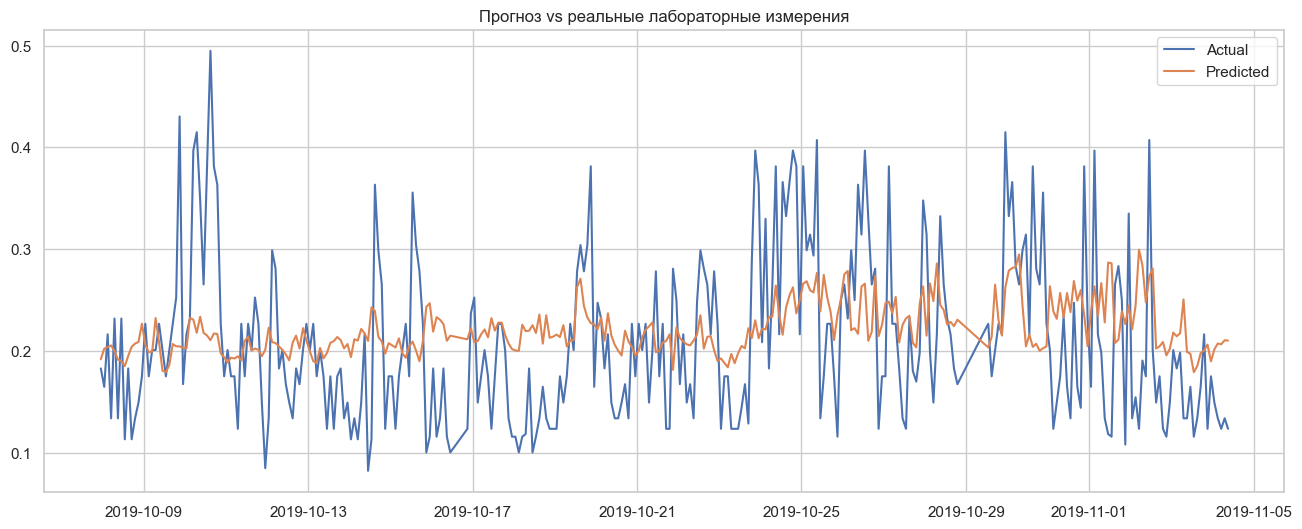

In [27]:
plt.figure(figsize=(16, 6))
plt.plot(test_ds["target_datetime"], y_test.values, label="Actual")
plt.plot(test_ds["target_datetime"], pred_test, label="Predicted")
plt.title("Прогноз vs реальные лабораторные измерения")
plt.legend()
plt.show()

### Вывод
На тестовой выборке проверяется, насколько хорошо модель воспроизводит реальные лабораторные измерения и улавливает направление изменения целевого показателя.

## 14. Анализ остатков

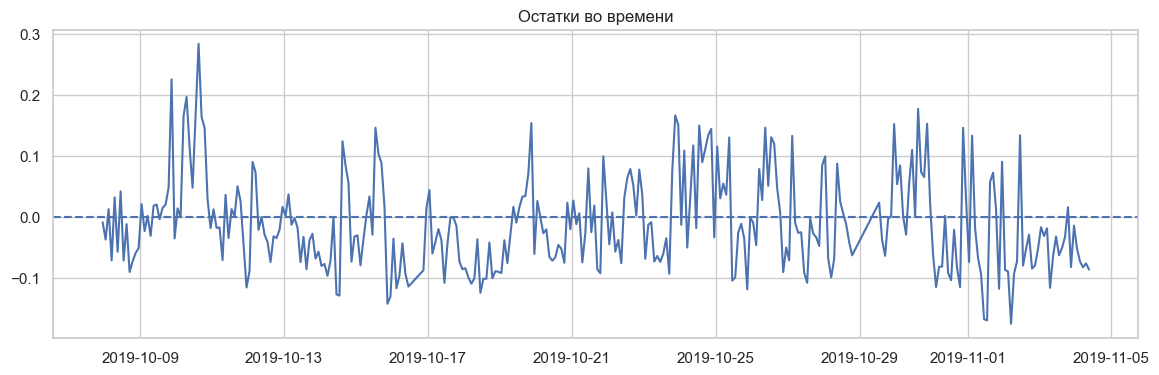

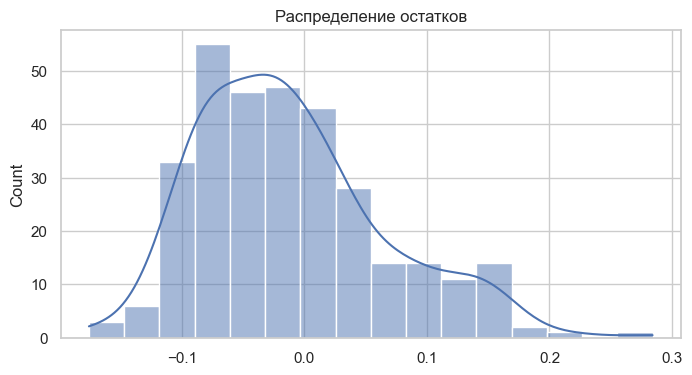

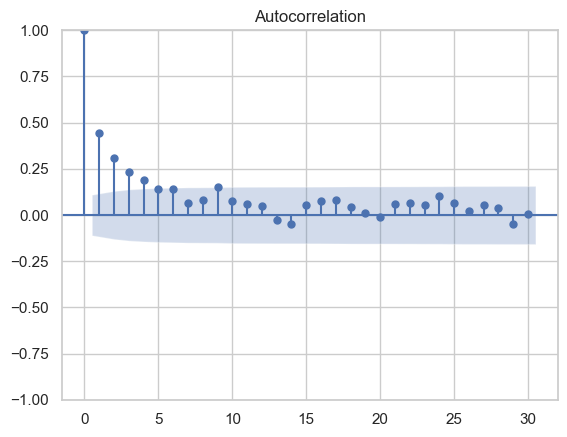

In [28]:
residuals = y_test.values - pred_test

plt.figure(figsize=(14, 4))
plt.plot(test_ds["target_datetime"], residuals)
plt.axhline(0, linestyle="--")
plt.title("Остатки во времени")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title("Распределение остатков")
plt.show()

plot_acf(residuals, lags=30)
plt.show()

In [29]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)
print("Jarque-Bera p-value:", jb_pvalue)

ljung = acorr_ljungbox(residuals, lags=[10], return_df=True)
display(ljung)

X_bp = sm.add_constant(pred_test)
bp = het_breuschpagan(residuals, X_bp)
print("Breusch-Pagan p-value:", bp[1])

Jarque-Bera p-value: 4.993901408185177e-08


,lb_stat,lb_pvalue
10,149.183468,5.487462e-27


Breusch-Pagan p-value: 0.00015843335901499336


### Вывод
Если остатки имеют выраженную структуру, автокорреляцию или меняющуюся дисперсию, это означает, что модель не полностью описывает динамику технологического процесса.

## 15. Важность признаков и интерпретация

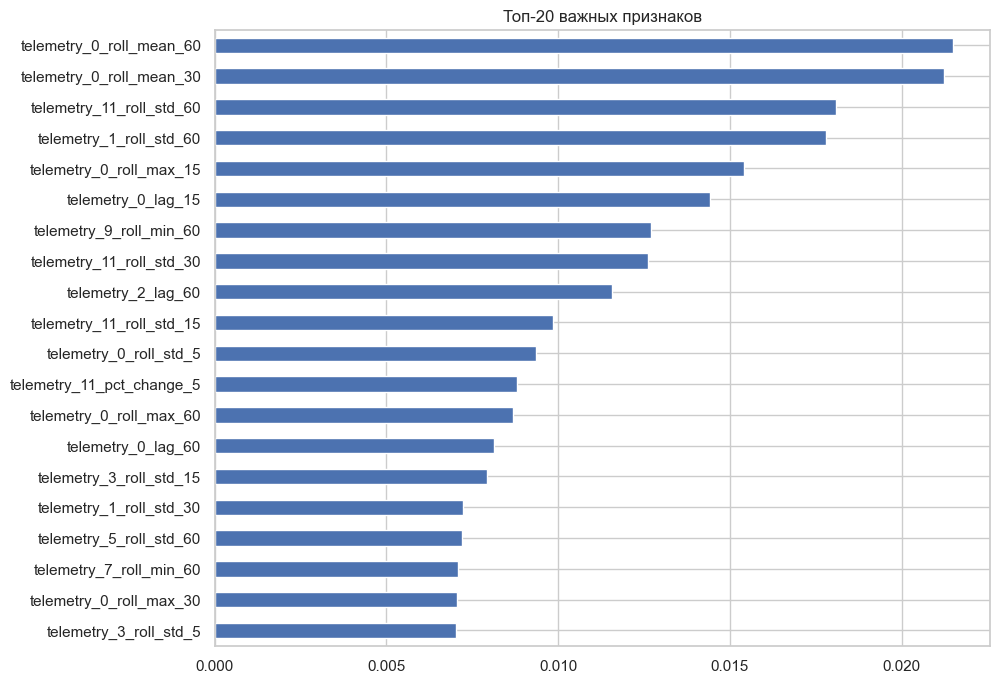

In [30]:
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    fi.sort_values().plot(kind="barh")
    plt.title("Топ-20 важных признаков")
    plt.show()
else:
    print("У выбранной модели нет встроенной feature importance.")

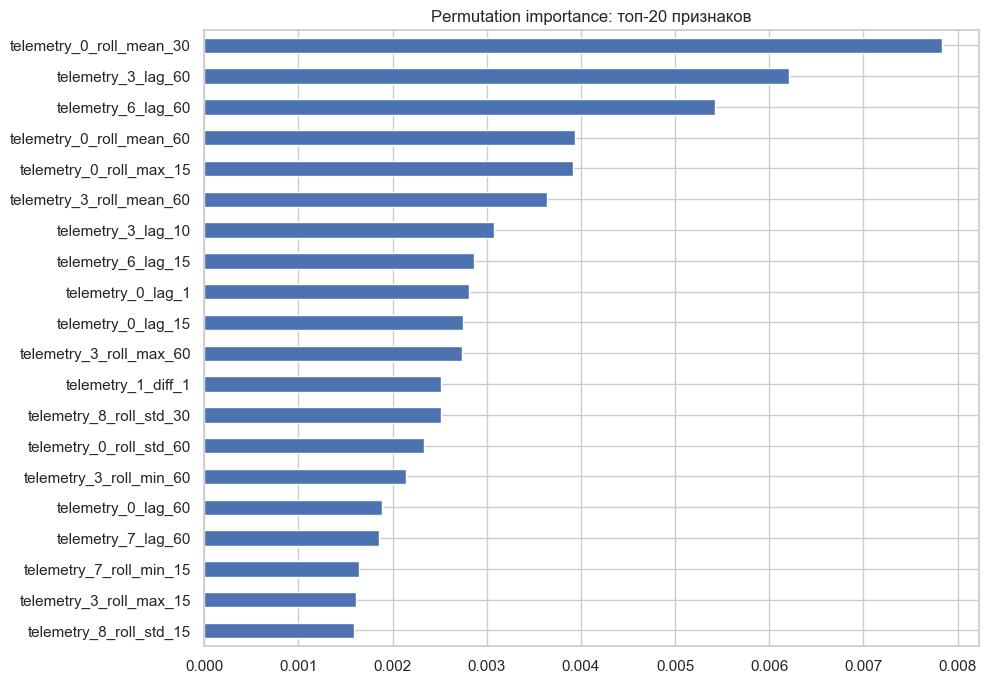

In [31]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
perm_imp.sort_values().plot(kind="barh")
plt.title("Permutation importance: топ-20 признаков")
plt.show()

### Интерпретация
Если среди наиболее важных признаков доминируют конкретные датчики, их лаги и скользящие статистики, это подтверждает, что модель использует физически осмысленные закономерности процесса, а не случайный шум.

## 16. Сравнение моделей по вычислительной эффективности

In [32]:
comparison_table = summary.copy()
comparison_table["comment"] = comparison_table["model"].map({
    "Ridge": "быстро, интерпретируемо",
    "RandomForest": "нелинейности, средняя скорость",
    "GradientBoosting": "сильный табличный baseline, тяжелее linear"
})
display(comparison_table)

,model,MAE,RMSE,MAPE,WAPE,Direction_Accuracy,fit_time_sec,comment
0,RandomForest,0.070694,0.088239,31.842484,27.566179,0.535616,1.420494,"нелинейности, средняя скорость"
1,GradientBoosting,0.072748,0.090534,32.716950,28.320368,0.517808,10.710415,"сильный табличный baseline, тяжелее linear"
2,Ridge,0.072447,0.090800,32.699785,28.243049,0.526712,0.010816,"быстро, интерпретируемо"


### Комментарий
AIC/BIC корректно применять к статистическим моделям вроде ARIMA. В данной задаче основной акцент сделан на ML-моделях с многомерной телеметрией, поэтому сравнение выполняется по качеству, устойчивости, интерпретируемости и времени обучения.

## 17. Сохранение результатов

In [33]:
OUTPUT_DIR = os.path.join("outputs", "metrics")
os.makedirs(OUTPUT_DIR, exist_ok=True)

summary.to_csv(os.path.join(OUTPUT_DIR, "model_cv_summary.csv"), index=False)
pd.DataFrame(delay_results).to_csv(os.path.join(OUTPUT_DIR, "delay_comparison.csv"), index=False)
pd.DataFrame([test_metrics]).to_csv(os.path.join(OUTPUT_DIR, "test_metrics.csv"), index=False)

print(f"Результаты сохранены в {OUTPUT_DIR}")

Результаты сохранены в outputs\metrics


## 18. Финальные выводы

## Итоговые выводы

### 1. По данным
Телеметрия имеет минутную частоту и хорошо описывает поведение технологического процесса. Лабораторные замеры являются редкими и запаздывающими, поэтому прямое сопоставление без временного сдвига некорректно.

### 2. По синхронизации
Для корректного обучения необходимо учитывать задержку между отбором пробы и получением результата анализа. Оптимальная задержка выбирается по качеству на временной кросс-валидации.

### 3. По признакам
Наиболее полезны признаки, отражающие:
- инерцию процесса,
- краткосрочную и среднесрочную динамику,
- локальные режимы работы печи.

### 4. По моделям
Линейная модель дает интерпретируемый baseline, а ансамблевые методы позволяют лучше описывать нелинейную структуру производственного процесса.

### 5. По бизнес-ценности
Построенная модель может использоваться как soft sensor для оперативной оценки концентрации целевого продукта до получения лабораторного результата. Это позволяет быстрее выявлять нештатные ситуации и снижать риск выпуска некачественной продукции.

### 6. Ограничения
- target измеряется редко и нерегулярно,
- лабораторная задержка задается приближенно,
- часть датчиков содержит пропуски,
- возможен дрейф режима работы оборудования.